### Programa de Formación en ML&DS
## Módulo NLP

# SESIÓN 10 - Análisis No Supervisado de Texto

### Por Elizabeth León Guzmán
---

# Análisis no supervisado de texto

Hasta el momento, hemos visto técnicas de aprendizaje supervisado para casos con textos **etiquetados**. Sin embargo, una gran cantidad de los datos textuales que se generan no contienen etiquetas, por lo que realizar un modelo de clasificación no es posible. En estos casos, se deben aplicar modelos **descriptivos** usando técnicas de aprendizaje no supervisado. Esto con el fin de explicar el comportamiento de los datos, ya que contienen información semántica de gran útilidad.


Este problema (no contar con etiqueta) es un tema recurrente en procesamiento de lenguaje natural, más específicamente, es un problema relacionado al entendimiento de grandes corpus a través de la identificación de un número de tópicos o temas comunes entre varios documentos. Entonces, el problema se reduce a describir un conjunto de textos sin etiquetas construyendo un modelo que encontre los temas o *topics* de manera no supervisada.

**Ejemplos:**

Algunos ejemplos son:


* *Música*:
  Identificar canciones similares por la letra de la canción, en lugar de usar el género, el artista, el año o el albúm.
  
* *Opinión*:
  Identificar opiniones o tendencias de marcas o noticias de los documentos generados en redes sociales o periódicos.


* Encontrar los géneros en un corpus conformado por todos los libros en una biblioteca.
* Encontrar los *estilos* de escritores en posts de redes sociales.
* Encontar géneros de películas en documentos con sinápsis.
* *Bioinformática*:

![topic_example](https://kldavenport.com/topic-modeling-amazon-reviews/image0.png)

Como una primera aproximación, introduciremos algunos de los métodos básicos para la identificación de tópicos por medio de técnicas de **clustering** como K-means, affinity propagation o hierarchical clustering. En esta sesión, utilizaremos el dataset [TMDB](https://www.kaggle.com/tmdb/tmdb-movie-metadata/download), el cual contiene resumenes de **películas** con anotaciones de géneros:

In [ ]:
!wget -O movies.csv https://raw.githubusercontent.com/larajuse/share/master/movies.csv

--2019-10-16 00:29:35--  https://raw.githubusercontent.com/larajuse/share/master/movies.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5698602 (5.4M) [text/plain]
Saving to: ‘movies.csv’

movies.csv          100%[===================>]   5.43M  --.-KB/s    in 0.1s    

2019-10-16 00:29:35 (51.2 MB/s) - ‘movies.csv’ saved [5698602/5698602]



In [ ]:
# Se importan las librerías
import numpy as np
np.random.seed(0)
import pandas as pd
import json, nltk, re
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use("ggplot")

# Se carga el conjunto de datos "movies". Este se compone de: resumen, generos y título
df=pd.read_csv("movies.csv")
df.dropna(axis=0,subset=["overview","genres","title"], inplace=True)
# en corpus se asigna solo el resumen
corpus=df.overview.tolist()
# en genres se asigna solo el genero
genres=list(map(lambda i: [j["name"] for j in json.loads(i.replace("'", "\""))], df.genres.tolist()))
# en title solo el título
titles=df.title.tolist()
# se baja popular
nltk.download("popular")

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

True

In [ ]:
# Para revisar, se imprimen los titulos en t, géneros en g y resumen en c (del resumen solo se imprimen 40 caracteres)
for c,g,t in zip(corpus[:3], genres[:3], titles[:3]):
    print("* Título: {}, géneros: {}, resumen: {}...".format(t,g,c[:40]))

* Título: Avatar, géneros: ['Action', 'Adventure', 'Fantasy', 'Science Fiction'], resumen: In the 22nd century, a paraplegic Marine...
* Título: Pirates of the Caribbean: At World's End, géneros: ['Adventure', 'Fantasy', 'Action'], resumen: Captain Barbossa, long believed to be de...
* Título: Spectre, géneros: ['Action', 'Adventure', 'Crime'], resumen: A cryptic message from Bond’s past sends...


## Preprocesamiento

Utilizaremos las mismas técnicas de preprocesamiento que hemos venido aplicando a lo largo del curso. Más específicamente, convertiremos el corpus (resumenes) a minúsculas, separaremos los signos de puntuación y elíminaremos stopwords y caracteres especiales.

In [ ]:
# El resumen de las películas esta en el corpus
def preprocessing(doc):
    wpt=nltk.WordPunctTokenizer()
    stop_words=nltk.corpus.stopwords.words('english')
    # Se eliminan caracteres especiales
    doc=re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)
    # Se convierten los téxtos a minúsculas
    doc=doc.lower()
    # Se separan signos de puntuación
    tokens=wpt.tokenize(doc)
    # Se eliminan las stopwords
    tokens=[token for token in tokens if token not in stop_words]
    # Retornamos una versión filtrada del texto
    return ' '.join(tokens)
norm_corpus=list(map(preprocessing,corpus))
norm_corpus[:3]

['nd century paraplegic marine dispatched moon pandora unique mission becomes torn following orders protecting alien civilization',
 'captain barbossa long believed dead come back life headed edge earth turner elizabeth swann nothing quite seems',
 'cryptic message bonds past sends trail uncover sinister organization battles political forces keep secret service alive bond peels back layers deceit reveal terrible truth behind spectre']

## Representación

Para representar cada documento utilizaremos Word2Vec,  este modelo se entrenará utilizando todo el corpus (resumenes) de películas. Además, la representación de un documento será el promedio de la representación de cada uno de sus términos. Con el propósito de visualizar los resultados, utilizaremos t-SNE (técnica para reducción de dimensionalidad) para obtener vectores bidimensionales $\vec{x_j}\in \mathbb{R}^2$.

***Nota: una dimensión vectorial tan pequeña no es muy recomendada, acá lo usamos sólo para visualizar el funcionamiento de métodos no supervisados***

In [ ]:
# Se construye una representación word2vect de 50 dimensiones, con una ventana de contexto de 3, usando 100 iteraciones en el modelo de aprendizaje
from gensim.models import word2vec
feature_size = 50
window_context = 3
min_word_count = 1
sample = 1e-3
wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(document) for document in norm_corpus]
w2v_model = word2vec.Word2Vec(tokenized_corpus, size=feature_size,
                              window=window_context, min_count=min_word_count,
                              sample=sample, iter=100)

In [ ]:
# Se construye la representación de los documentos como el promedio de la representación de cada una de sus palabras.
def w2v_repr(corpus):
    w2v_representations=[]
    tokenized_corpus=[wpt.tokenize(document) for document in corpus]
    for sentence in tokenized_corpus:
        try:
            w2v_representations.append(w2v_model.wv[sentence].mean(axis=0))
        except:
            w2v_representations.append(np.zeros(shape=(feature_size,)))
    return np.array(w2v_representations)
# se aplica técnica de reducción de dimensiones para visualizar en dos dimensiones (solo con fines de visualización)
X_w2v=w2v_repr(norm_corpus)
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2, random_state=0, n_iter=1000, perplexity=2, verbose=1)
T=tsne.fit_transform(X_w2v)

[t-SNE] Computing 7 nearest neighbors...
[t-SNE] Indexed 4800 samples in 0.010s...
[t-SNE] Computed neighbors for 4800 samples in 2.563s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4800
[t-SNE] Computed conditional probabilities for sample 2000 / 4800
[t-SNE] Computed conditional probabilities for sample 3000 / 4800
[t-SNE] Computed conditional probabilities for sample 4000 / 4800
[t-SNE] Computed conditional probabilities for sample 4800 / 4800
[t-SNE] Mean sigma: 0.362347
[t-SNE] KL divergence after 250 iterations with early exaggeration: 111.373497
[t-SNE] KL divergence after 1000 iterations: 2.384903


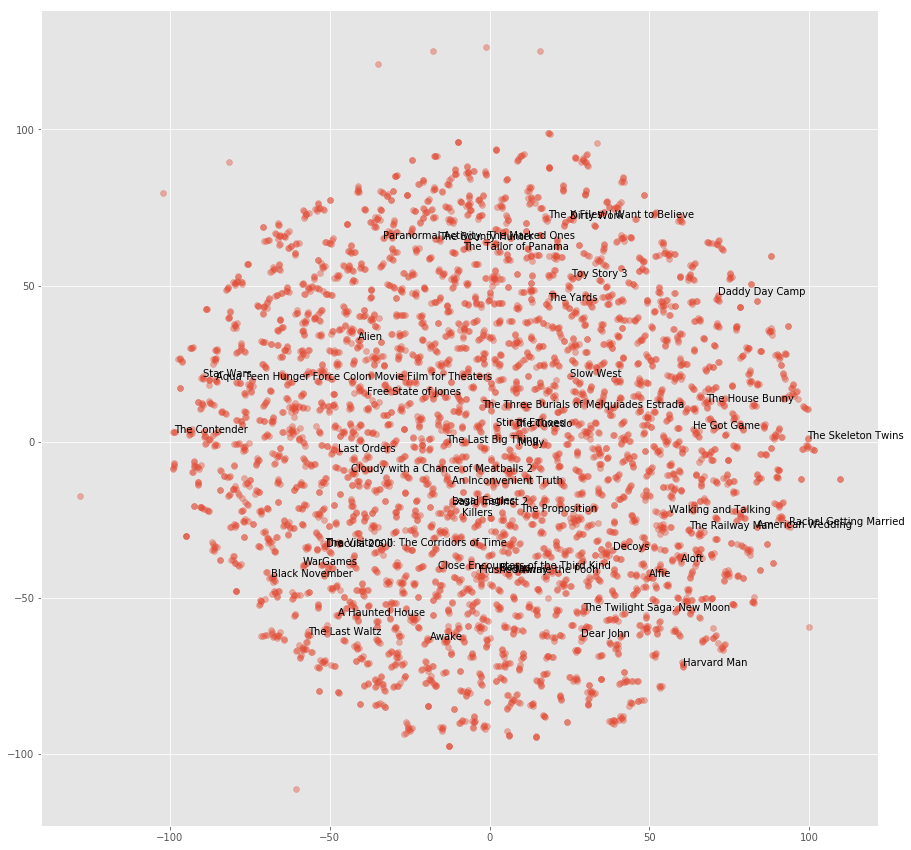

In [ ]:
# Se dibuja cada película. ¿Qué se puede concluir?
plt.figure(figsize=(15, 15))
n_docs=50
idx=np.arange(len(corpus))
valid_idx=np.random.choice(idx, replace=False, size=n_docs)
plt.scatter(T[:, 0], T[:, 1], alpha=0.4)
viz_titles=[titles[i] for i in valid_idx]
for label, x, y in zip(viz_titles, T[valid_idx, 0], T[valid_idx, 1]):
    plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')

# Agrupación

## K-means

Se trata del método más básico de clustering y consiste en estimar de forma automática grupos dentro de la representación de los datos, de tal fomra que los puntos u objetos mas parecidos queden en el mismo grupo y los grupos entre sí sean lo más diferentes posible. En la siguiente figura se muestra como el algoritmo encuentra los grupos después de varias iteraciones:

![k-means](https://raw.githubusercontent.com/larajuse/share/master/kmeans.gif)

En K-means los datos son asignados al grupo más cercano utilizando la distancia euclidiana $||\vec{x}-\vec{y}||=\sqrt{\sum_{i=1}^{m}(x_i-y_i)^2}$. Y como su nombre lo indica, el problema consiste en determinar $K$ clusters, representando cada uno por su centroide o media $\vec{\mu}_i$. Lo cual, puede ser visto como un problema de optimización con la siguiente función de pérdida a minimizar:

$$
\mathcal{L}=\sum_{i=1}^{K}\sum_{\vec{x_j} \in \mathbf{X}} ||\vec{x_j}-\vec{\mu}_i||
$$

Donde $\mathbf{X}=\{\vec{x}_1,\vec{x}_2, \dots, \vec{x}_N\}$ son las representaciones de los documentos y $\mu_i$ es el centroide más cercano a la representación $\vec{x_j}$.

Veamos un ejemplo con una versión muy simple de K-means:

Text(0, 0.5, '$x_2$')

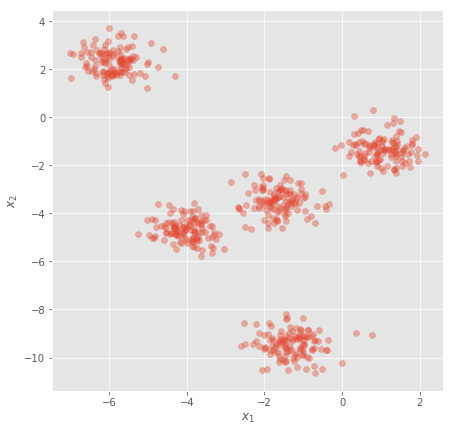

In [ ]:
from sklearn.datasets import make_blobs
np.random.seed(2)
# Creamos un dataset sintético
X,_=make_blobs(n_samples=600,centers=5, cluster_std=0.5)
plt.figure(figsize=(7,7))
plt.scatter(X[:,0],X[:,1],alpha=0.4)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances
def simple_kmeans(X,k, iter=100):
    init_clus=np.random.choice(np.arange(X.shape[0]),replace=False, size=k)
    clusters=X[init_clus]
    preds=np.argmin(euclidean_distances(X,clusters),axis=1)
    all_clusters=[clusters.copy()]
    all_preds=[preds]
    for i in range(iter):
        for clus in range(k):
            clusters[clus]=X[preds==clus].mean(axis=0)
            all_clusters.append(clusters.copy())
            preds=np.argmin(euclidean_distances(X,clusters),axis=1)
            all_preds.append(preds.copy())
    return all_clusters,all_preds

all_clusters,all_preds=simple_kmeans(X,5)

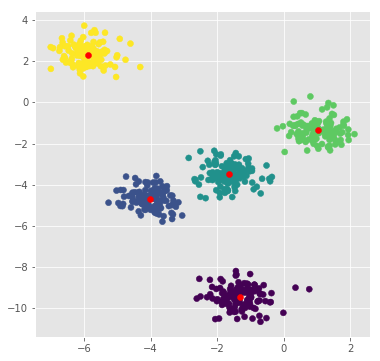

In [ ]:
# Iteración 0. Se realiza la inicialización aleatoriamente, para el ejemplo son 5 puntos,
# y los demas puntos se asignan al cluster más cercano.

iteration=51 #@param {type:"slider", min:0, max:100, step:1}
plt.figure(figsize=(6,6))
plt.scatter(X[:,0],X[:,1],c=all_preds[iteration])
plt.scatter(all_clusters[iteration][:,0],all_clusters[iteration][:,1],c="r")


Ahora veamos los grupos en la implementación de K-means en sklearn:

Text(0, 0.5, '$x_2$')

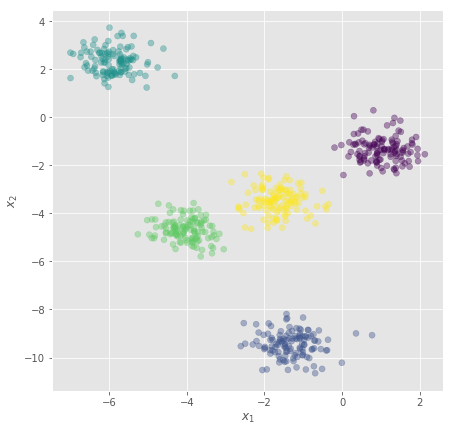

In [ ]:
from sklearn.cluster import KMeans
clf=KMeans(n_clusters=5)
clf.fit(X)
clusters_pred=clf.predict(X)
plt.figure(figsize=(7,7))
plt.scatter(X[:,0],X[:,1],c=clusters_pred,alpha=0.4)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

Podemos observar que K-means permite identificar zonas de alta densidad en el espacio de la representación. Ahora, retomaremos el caso del dataset de películas para ver qué patrones se identifican con este método. En este caso se desea **agrupar las películas**, es decir que en cada grupo deben quedar las películas más parecidas, y los grupos entre sí deben estar lo más alejados posible. El agrupar documentos por contenido se conoce como **Document clustering**

In [ ]:
# comenzaremos encontrando 4 clusters.
clf=KMeans(n_clusters=4)
clf.fit(X_w2v)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

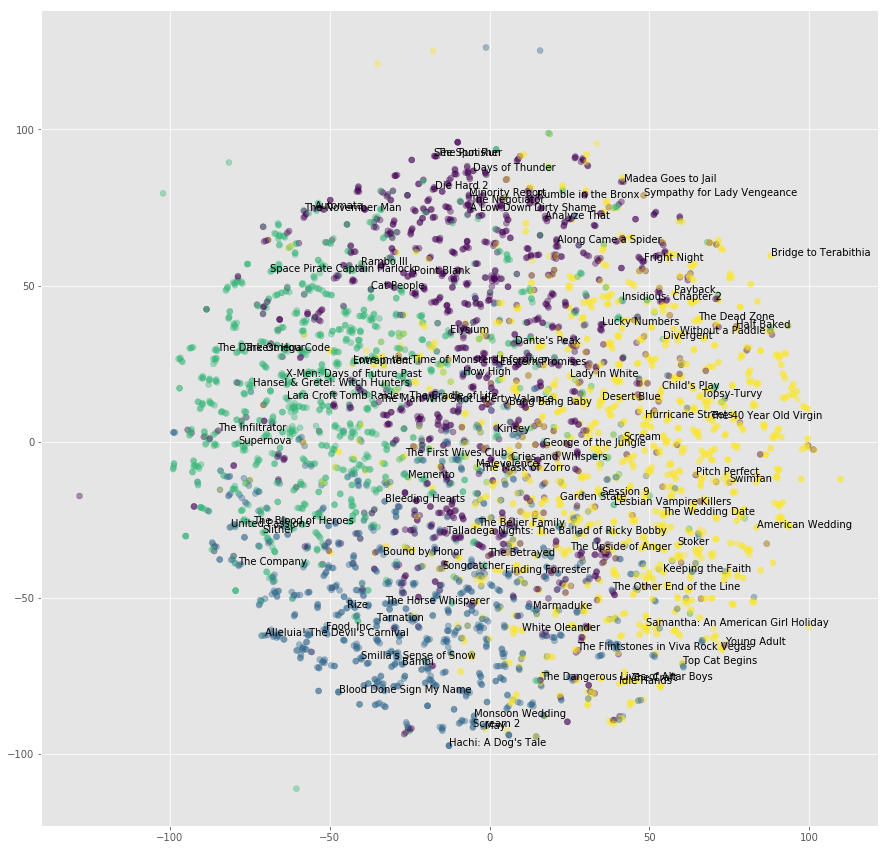

In [ ]:
# Visualizamos los clusters en 2 dimensiones. Otra forma de entender cada uno de los clusters es dibujar la nube de palabras.
clusters=clf.predict(X_w2v)
plt.figure(figsize=(15, 15))
n_docs=100
idx=np.arange(len(corpus))
valid_idx=np.random.choice(idx, replace=False, size=n_docs)
plt.scatter(T[:, 0], T[:, 1], c=clusters, alpha=0.4)
viz_titles=[titles[i] for i in valid_idx]
for label, x, y in zip(viz_titles, T[valid_idx, 0], T[valid_idx, 1]):
    plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')

Veamos algunos ejemplos de películas en cada uno de los clusters:

In [ ]:
idx=np.arange(X_w2v.shape[0])
for clus in range(4):
    example_idxs=np.random.choice(idx[clusters==clus],10)
    examples=[titles[i] for i in example_idxs]
    print("Ejemplos aleatorios dentro del cluster {}".format(clus))
    print(examples)

Ejemplos aleatorios dentro del cluster 0
['The Hustler', 'Edmond', 'The Missing Person', "Big Momma's House", 'Home Run', 'An Alan Smithee Film: Burn, Hollywood, Burn', 'Out of Time', 'The Gambler', 'The Ladies Man', 'Final Destination 2']
Ejemplos aleatorios dentro del cluster 1
['Ever After: A Cinderella Story', 'Born to Fly: Elizabeth Streb vs. Gravity', 'Auto Focus', 'Illuminata', 'Big Eyes', 'Fuel', 'Hedwig and the Angry Inch', 'Vessel', 'The Artist', 'American Dreamz']
Ejemplos aleatorios dentro del cluster 2
['Riddick', 'Falcon Rising', 'The Purge', 'The Snow Queen', 'Daylight', 'Austin Powers in Goldmember', 'Percy Jackson & the Olympians: The Lightning Thief', 'Everest', 'Final Destination 5', 'Predators']
Ejemplos aleatorios dentro del cluster 3
['I Served the King of England', 'Metropolis', 'Shark Lake', 'White Oleander', 'Scream', 'Stand by Me', 'Ted', 'The Lost Skeleton of Cadavra', 'Stolen Summer', 'School Daze']


Ahora, podemos visualizar una nube de palabras con los términos más relevantes de cada cluster con el fin de interpretar qué relaciones semánticas está aprendiendo K-means:

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


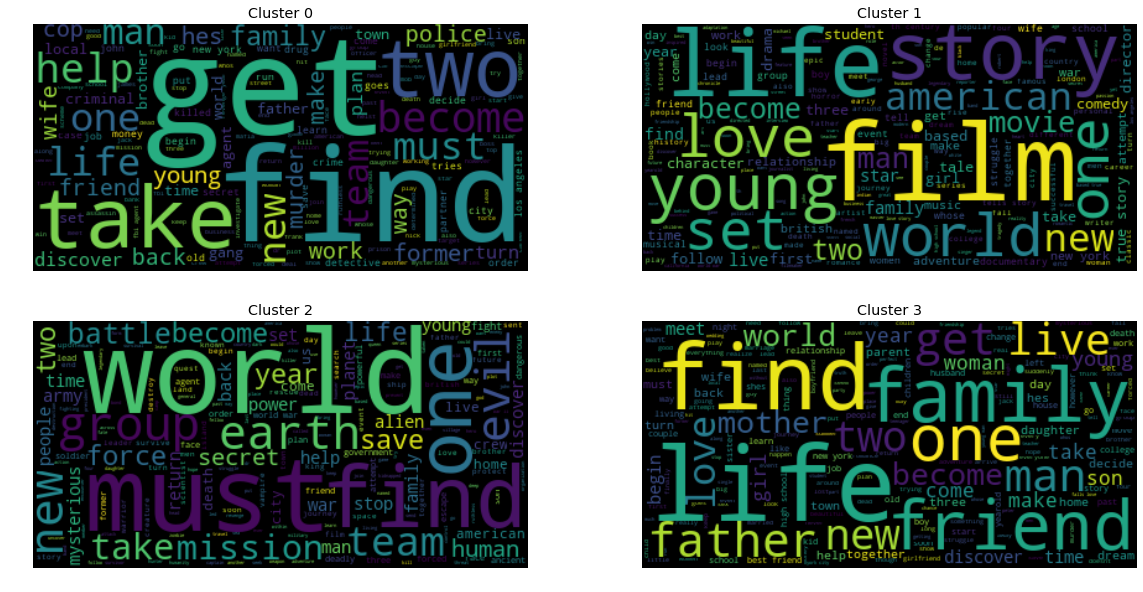

In [ ]:
# Nube de palabras
from wordcloud import WordCloud
nltk.download("stopwords")
from nltk.corpus import stopwords
from functools import reduce
idx=np.arange(len(norm_corpus))
plt.figure(figsize=(20,10))
for clus in range(4):
    all_words=reduce(lambda a,b:a+" "+b, [norm_corpus[i] for i in idx[clusters==clus]])
    im=WordCloud(stopwords=stopwords.words("english")).generate(all_words)
    plt.subplot(221+clus)
    plt.imshow(im,interpolation="bilinear")
    plt.axis("off")
    plt.title("Cluster {}".format(clus))

Finalmente, veamos la proporción original de géneros dentro de cada uno de los clusters encontrados. Es decir vamos a utilizar la clasificación original que tiene la película y comparar con nuestros grupos:
¿Qué podemos concluir?

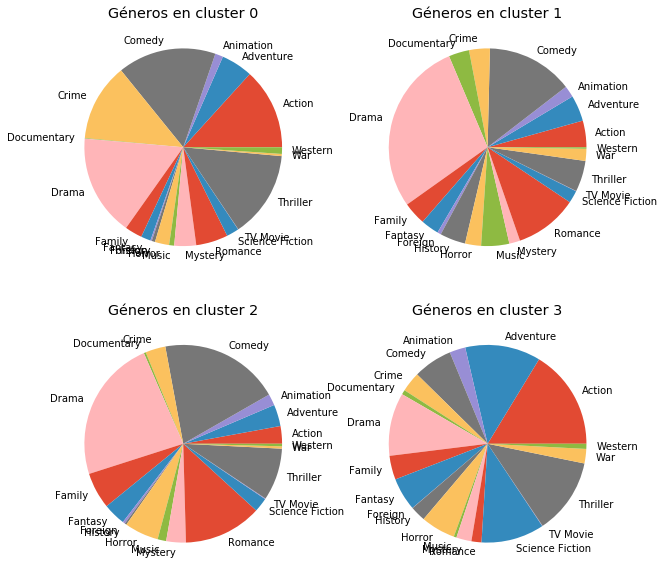

In [ ]:
from functools import reduce
plt.figure(figsize=(10,10))
for clus in range(4):
    plt.subplot(221+clus)
    example_idxs=idx[clusters==clus]
    exam_genres=reduce(lambda a,b:a+b,[genres[i] for i in example_idxs])
    names,counts=np.unique(exam_genres,return_counts=True)
    counts=counts/counts.sum()
    plt.pie(counts, labels=names)
    plt.title("Géneros en cluster {}".format(clus))

Una de las principales desventajas de K-means es que se debe escoger un número de clusters $K$. Generalmente, se selecciona utilizando información previa o por medio de un análisis exploratorio.

En este caso, exploraremos cuáles son los efectos de la variación de $K$ sobre la pérdida de K-means $\mathcal{L}$ (la cual definimos anteriormente).



In [ ]:
ks=np.arange(1,200,10)
scores=[]
for k in ks:
    clf=KMeans(n_clusters=k)
    clf.fit(X_w2v)
    scores.append(-clf.score(X_w2v))

Text(0, 0.5, '$\\mathcal{L}$')

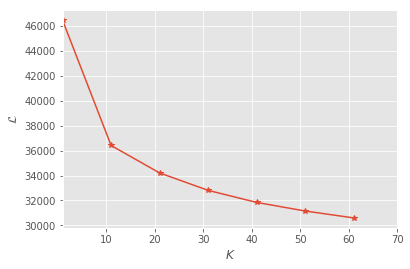

In [ ]:
plt.plot(ks,scores,"*-")
plt.xlim([1,190])
plt.xlabel("$K$")
plt.ylabel("$\mathcal{L}$")

Esta gráfica provee información importante para la selección del número de clusters. Se trata de un *trade-off* entre un modelo más pequeño (menor número de clusters) y una pérdida menor. Lo ideal, es aprovechar el comportamiento exponencial de esta curva y seleccionar un número de clusters que reduzca de forma considerable la pérdida sin la necesidad de tener un modelo muy grande.

## Affinity propagation

Una alternativa a K-means es affinity propagation (AP). Se trata de un método basado en grafos que calcula de forma automática el numérico de clusters $K$ en un dataset.

![affinity_propagation](https://www.ritchievink.com/img/post-14-affinity_propagation/preference_median.gif)

Una forma intuitiva de entender AP es suponiendo que los datos son un grafo, donde cada punto está envíando mensajes a todos los demás de forma continúa. El objetivo de estos mensajes es determinar la voluntad o complacencia de un conjunto de puntos representativos conocidos como ejemplares (análogo a los clusters en K-means). Cada punto busca determinar de forma colectiva los puntos que son representativos para cada uno por medio de dos matrices:

* Una matriz de responsabilidad $\mathbf{R}$, donde cada elemento $r_{i,k}$ representa qué tan adecuado es un punto $k$ para ser ejemplar de un punto $i$.
* Una matriz de disponibilidad $\mathbf{A}$, donde cada elemento $a_{i,k}$ representa qué tan apropiado sería para un punto $i$ escoger a un punto $k$ como su ejemplar.

Estas dos matríces representan un grafo donde cada punto está conectado con todos los otros puntos, por ejemplo:

![ap_graph](https://www.ritchievink.com/img/post-14-affinity_propagation/graph.svg)

En AP las matrices de responsabilidad y disponibilidad se modifican en base a una medida de similitud entre los datos (por ejemplo, la distancia euclidiana produce resultados similares a K-means), dicha similitud se codifica como una matríz $\mathbf{S}$ donde cada elemento $s_{i,k}$ representa la similitud entre un punto $i$ y un punto $k$.

En la práctica, affinity propagation usa los siguientes parámetros:

* *affinity*: define la medida de similitud, en sklearn se puede usar "euclidian" o "precomputed". En el segundo caso se debe calcular una matríz de similitud con la distancia deseada.
* *damping*: se trata de un parámetro usado en la implementación de affinity propagation que es análogo a una taza de aprendizaje (los autores del método sugieren valores entre 0.5 y 1). Un valor cercano a 0.5 genera un mayor número de clusters mientras un valor cercano a 1 genera un menor número de clusters.
* *max_iter*: como se trata de un método iterativo, requiere un número máximo de iteraciones.

Veamos un ejemplo de la aplicación de Affinity Propagation con el mismo dataset sintético que utilizamos con K-means:

Text(0, 0.5, '$x_2$')

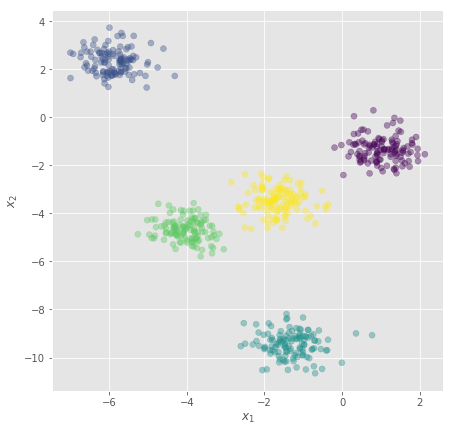

In [ ]:
from sklearn.cluster import AffinityPropagation
clf=AffinityPropagation(damping=0.9)
clf.fit(X)
clusters_pred=clf.predict(X)
plt.figure(figsize=(7,7))
plt.scatter(X[:,0],X[:,1],c=clusters_pred,alpha=0.4)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

Podemos ver que el método encontró automáticamente que deben haber 3 puntos ejemplares. Ahora, retomemos el ejemplo con el dataset de películas para ver cuántos clusters estima AP.

In [ ]:
# comenzaremos encontrando 4 clusters.
clf=AffinityPropagation(damping=0.95)
clf.fit(X_w2v)

AffinityPropagation(affinity='euclidean', convergence_iter=15, copy=True,
                    damping=0.95, max_iter=200, preference=None, verbose=False)

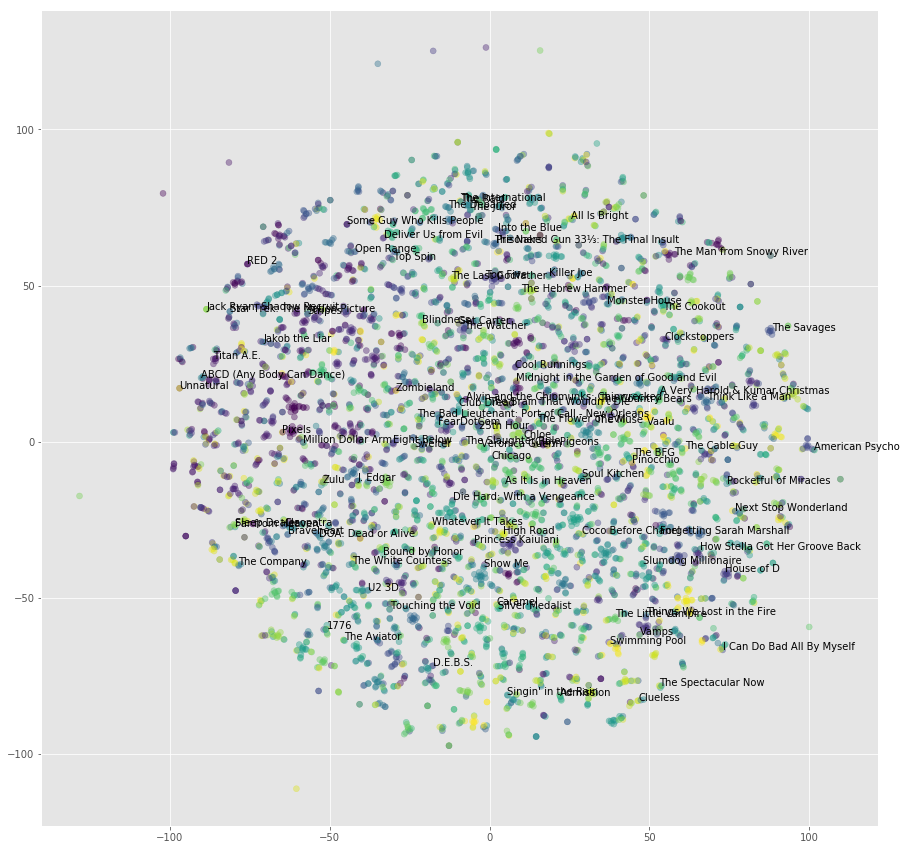

In [ ]:
clusters=clf.predict(X_w2v)
plt.figure(figsize=(15, 15))
n_docs=100
idx=np.arange(len(corpus))
valid_idx=np.random.choice(idx, replace=False, size=n_docs)
plt.scatter(T[:, 0], T[:, 1], c=clusters, alpha=0.4)
viz_titles=[titles[i] for i in valid_idx]
for label, x, y in zip(viz_titles, T[valid_idx, 0], T[valid_idx, 1]):
    plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')

In [ ]:
print("Affinity Propagation encontró {} clusters".format(clf.cluster_centers_.shape[0]))

Affinity Propagation encontró 263 clusters


## Hierarchical clustering

Se trata de un algoritmo que al igual que los métodos que hemos visto, agrupa objetos similares en clusters. No obstante, se trata de un método que encuentra relaciones no lineales entre los datos al construír una estructura básada en árboles de jerarquía.

![hierarchical_example](https://46gyn61z4i0t1u1pnq2bbk2e-wpengine.netdna-ssl.com/wp-content/uploads/2018/03/Screen-Shot-2018-03-28-at-11.48.48-am.png)

En general, hay dos tipos de hierarchical clustering: divisivo y aglomerativo.

### Divisive hierarchical clustering

Se trata de una técnica que no es muy usada en la práctica y utilza un enfoque opuesto al que utiliza el método aglomerativo. Consiste en asumir que inicialmente todos los puntos pertenecen a un mismo cluster e iterativamente dividirlo en varios grupos por medio de una medida de similitud.

El algoritmo más conocido que utiliza este tipo de clustering es *DIvisive ANAlysis Clustering* (DIANA), el cual, estima todas las posibles formas de obtener dos particiones de cada cluster con el fin de determinar la mejor forma de dividir los grupos más heterogéneos.

### Agglomerative hierarchical clustering

El enfoque aglomerativo es el tipo más común de hierarchical clustering, comienza suponiendo que cada uno de los puntos es un cluster, los cuales se irán fusionando a lo largo de las iteraciones hasta obtener un número deseado de clusters. El método consiste en los siguientes pasos:

1. Calcular una matríz de similitud $\mathbf{S}$.
2. Fusionar los dos clusters más cercanos.
3. Repetir desde el paso 1 hasta obtener un único cluster o un número $K$ de clusters.

Como un cluster puede estar compuesto por varios puntos, existen diversas formas de obtener similitudes:

* MIN: la similitud entre dos clusters es la mínima similitud o distancia entre los puntos de cada cluster.
![min_agglomerative](https://miro.medium.com/max/491/1*mtDL2TynaiwpJlhLdecFYQ.jpeg)
* MAX: la similitud entre dos clusters es la máxima distancia entre los puntos de cada cluster.
![max_agglomerative](https://miro.medium.com/max/491/1*nRYZyjoT1ZRzlWp3oP0_QQ.jpeg)
* Promedio: la similitud entre dos clusters es el promedio entre la similitud de todas las combinaciones de puntos de cada cluster.
![avg_agglomerative](https://miro.medium.com/max/491/1*CMHO0wpT8hCkR_xCQW2ggQ.jpeg)
* Distancia entre centroides: la similitud entre dos clusters es la similitud entre los puntos promedio o centroides de cada cluster.
![centroid_agglomerative](https://miro.medium.com/max/491/1*2AYd0CXANWsM8MLwmrJzYQ.jpeg)
* Ward: la similitud entre dos clusters es la suma de cuadrados media de todas las combinaciones de puntos de cada cluster.

Veamos la aplicación de agglomerative clustering:

In [ ]:
# importamos las librerías
from scipy.cluster.hierarchy import ward, dendrogram
from sklearn.metrics.pairwise import euclidean_distances

In [ ]:
# Calculamos la similitud entre cada punto del dataset
dists=euclidean_distances(X_w2v)

In [ ]:
# Construímos el árbol jerárquico
# la función ward retorna una matríz "linkage" con las relaciones de cada rama del árbol.
linkage_matrix=ward(dists)

/usr/local/lib/python3.6/dist-packages/scipy/cluster/hierarchy.py:830: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


El resultado es una matríz $\mathbf{L}$ de tamaño $(N-1)\times 4$. Cada fila $i$ contiene el resultado de cada iteración, y en las columnas se encuentra la siguiente información: $L_{i,0}$ y $L_{i,1}$ contienen los índices de los clusters que se unirán, $L_{i,2}$ contiene la similitud entre los dos clusters y $L_{i,3}$ contiene el número de puntos totales que hay en el cluster formado.

In [ ]:
linkage_matrix.shape

(4799, 4)

Una de las formas típicas de visualizar el resultado es con un dendograma, el cual, es una representación gráfica en forma de árbol con las relaciones determinadas. Veamos el dendograma:

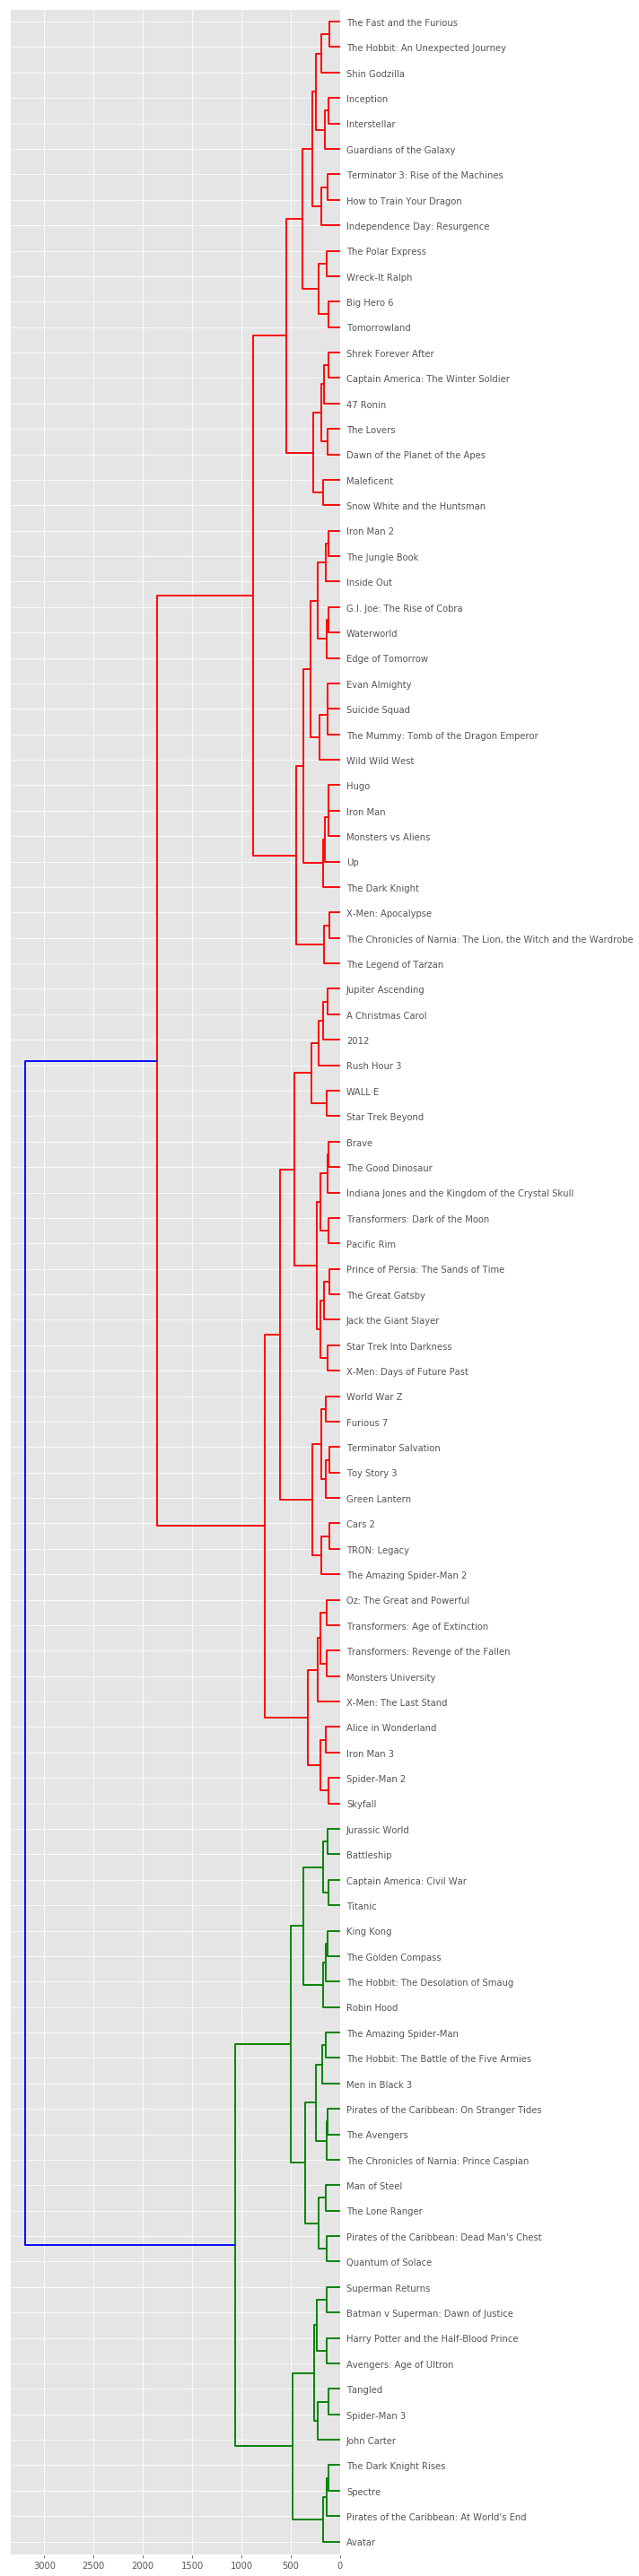

In [ ]:
fig,ax=plt.subplots(figsize=(10,40))
# Construímos el dendograma (árbol jerárquico)
R=dendrogram(linkage_matrix, orientation="left", labels=titles,
             truncate_mode='lastp', p=100, no_plot=False)
# Definimos una función para etiquetar cada una de las ramas del árbol.
def llf(x):
    # Asignamos cada uno de los títulos de las películas a cada una de las ramas
    temp={R["leaves"][i]: titles[i] for i in range(len(R["leaves"]))}
    return "{}".format(temp[x])
# Visualizamos el dendograma
ax=dendrogram(linkage_matrix, truncate_mode='lastp', orientation="left", p=100,
              leaf_label_func=llf, leaf_font_size=10.)
plt.tight_layout()

De igual forma que en K-means, en hierarchical clustering se puede especificar un número $K$ de clusters. Así mismo, cuando no poseemos información sobre el valor de $K$ apropiado para un problema en específico, podemos realizar un análisis exploratorio.

A diferencia de K-means, en este caso no se optimiza directamente una función de pérdida (la cual utilizamos para determinar un núúmero apropiado de clusters). No obstante, existen distintas métricas que pueden ser usadas para medir el desempeño en métodos de clustering. En el caso de Hierarchical Clustering, una de las métricas más usada es la distancia intercluster, consiste en obtener el promedio entre la similitud de todas las posibles combinaciones de puntos de distintos clusters. Veamos un ejemplo de distancias intercluster para un caso de $K=3$.


In [ ]:
# Version de Hierarchical clustering que permite seleccionar un número de clusters.
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=3, linkage="ward")
hc.fit(X_w2v)

AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
                        connectivity=None, distance_threshold=None,
                        linkage='ward', memory=None, n_clusters=3,
                        pooling_func='deprecated')

In [ ]:
# Obtenemos el cluster al que pertenece cada punto
preds=hc.labels_
# Calculamos la distancia inter cluster
inter_dists=np.zeros((3,3))
for i in range(3):
    for j in range(3):
        if i>j: inter_dists[i,j]=inter_dists[j,i]
        else:
            # Estimamos la distancia promedio entre el cluster i y el cluster j
            inter_dists[i,j]=euclidean_distances(X_w2v[preds==i],X_w2v[preds==j]).mean()

Text(0.5, 1.0, 'Distancias Intercluster Promedio')

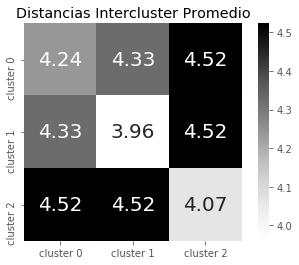

In [ ]:
class_names=["cluster {}".format(i) for i in range(3)]
sns.heatmap(inter_dists,square=True,annot=True,cbar=True,
            xticklabels=class_names,yticklabels=class_names,
            annot_kws={"size": 20},fmt=".2f",cmap="Greys")
plt.title("Distancias Intercluster Promedio")

Ahora, para determinar un valor de $K$ apropiado, utilizaremos una métrica comúnmente usada en la evaluación de métodos de clustering. El Davies-Bouldin score es una razón entre las distancias intracluster y las distancias intercluster, donde un valor menor representa un mejor resultado de clustering (mayor distancia intercluster y menor distancia intracluster). Veamos un ejemplo:

In [ ]:
from sklearn.metrics import davies_bouldin_score
ks=np.arange(2,5000,500)
scores=[]
for k in ks:
    hc=AgglomerativeClustering(n_clusters=k, linkage="ward")
    hc.fit(X_w2v)
    scores.append(davies_bouldin_score(X_w2v,hc.labels_))

Text(0, 0.5, 'Davies-Bouldin')

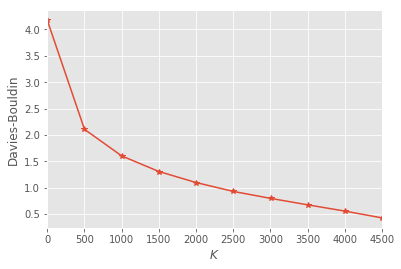

In [ ]:
plt.plot(ks,scores,"*-")
plt.xlim([1,4500])
plt.xlabel("$K$")
plt.ylabel("Davies-Bouldin")

## Ejercicio


Repita el procedimiento mostrado en Affinity Propagation y Hierarchical clustering utilizando la similitud coseno como médida de similitud. ¿mejoraron las relaciones?, discuta los resultados.




## Referencias

* https://medium.com/@MSalnikov/text-clustering-with-k-means-and-tf-idf-f099bcf95183
* https://www.ritchievink.com/blog/2018/05/18/algorithm-breakdown-affinity-propagation/
* https://www.displayr.com/what-is-hierarchical-clustering/
* https://towardsdatascience.com/understanding-the-concept-of-hierarchical-clustering-technique-c6e8243758ec
* https://www.datanovia.com/en/lessons/divisive-hierarchical-clustering/